### 1. Загрузка датасета

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [19]:
data = pd.read_csv('airbnb_data_for_modeling.csv.gz', sep = '\t')
data

,price,neighbourhood,lat,number_of_reviews,reviews_per_month,has_house_rules,days_since_last_review,neighbourhood_group_Manhattan,neighbourhood_group_Queens
0,966.0,0.037685,-1.443197,-0.372251,-0.565855,1.073279,-0.558177,-0.863076,-0.385734
1,142.0,0.310892,0.457386,0.355905,-0.464940,1.073279,-0.590809,1.158647,-0.385734
2,204.0,-0.666902,1.261278,-0.372251,-0.631153,1.073279,-0.395780,1.158647,-0.385734
3,577.0,0.454686,0.350833,0.942476,-0.340280,1.073279,-0.428565,1.158647,-0.385734
4,1060.0,-1.371490,-0.737798,0.436811,-0.453068,1.073279,-0.333261,-0.863076,-0.385734
...,...,...,...,...,...,...,...,...,...
101084,696.0,-0.479971,-1.408097,-0.311572,-0.429323,1.073279,-0.415298,-0.863076,-0.385734
101085,909.0,-1.155800,-0.525767,-0.169986,-0.263110,-0.931724,-0.327924,-0.863076,-0.385734
101086,387.0,-1.371490,-0.895031,0.457038,1.161574,1.073279,-0.429175,-0.863076,-0.385734
101087,848.0,-0.163626,1.511454,-0.554291,-0.690515,1.073279,2.326693,1.158647,-0.385734


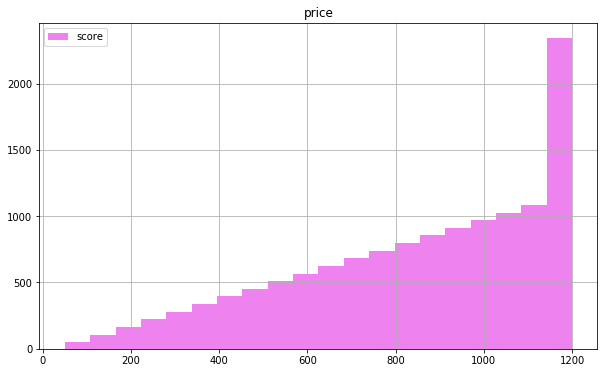

In [20]:
# Посмотрим на распределение целевого признака

import matplotlib.pyplot as plt
import seaborn as sns
        
bins = 20

plt.rcParams["figure.figsize"] = (10,6)
fig, ax = plt.subplots()

x = data['price'].values
n_x, bins_x = np.histogram(x, bins = bins)

ax.set(title = "price")
plt.hist(bins_x, bins, weights = bins_x, color = 'violet', label = "score")

ax.legend()
ax.grid()
plt.show()

Как мы видим, в рассматриваемых данных присутствует приемлемый дисбаланс классов.

Переведём целевую переменную в логарифм:

In [22]:
data['price'] = np.log(data['price'])

In [25]:
data.head()

,price,neighbourhood,lat,number_of_reviews,reviews_per_month,has_house_rules,days_since_last_review,neighbourhood_group_Manhattan,neighbourhood_group_Queens
0,6.873164,0.037685,-1.443197,-0.372251,-0.565855,1.073279,-0.558177,-0.863076,-0.385734
1,4.955827,0.310892,0.457386,0.355905,-0.464940,1.073279,-0.590809,1.158647,-0.385734
2,5.318120,-0.666902,1.261278,-0.372251,-0.631153,1.073279,-0.395780,1.158647,-0.385734
3,6.357842,0.454686,0.350833,0.942476,-0.340280,1.073279,-0.428565,1.158647,-0.385734
4,6.966024,-1.371490,-0.737798,0.436811,-0.453068,1.073279,-0.333261,-0.863076,-0.385734


.

### 2. Метрики для оценки качества

В качестве метрик для решения задачи регрессии будем использовать:

1. **Среднеквадратическая ошибка RMSE**  
Данная метрика позволяет оценить среднеквадратическую ошибку предсказания, однако, в отличие от метрики MSE, даёт возможность оценить разницу в тех же единицах измерения, что и целевая переменная. Обычно данная оценка не очень полезна, т.к. показывает величину, а не относительное значение. Однако в нашем случае она будет полезна, поскольку предсказываемая величина лежит в известных нам границах. Понятно, что чем меньше значение ошибки, тем лучше работает наша модель.
  
  
2. **MAE - средняя абсолютная ошибка**   
Считается как среднее модуля разницы между предиктом и реальными значениями.
  
  
3. **R² - коэффициент детерминации**    
Соотношение качества между результатами модели и случайными предсказаниями. Данная величина является безразмерной и может принимать значения от 1 (лучший случай) до минус бесконечности, что означает, что построенная модель работает хуже рандома.
  
  
4. **MAPE - средняя процентная ошибка**  
Данная величина считается как отношение разницы между предиктом и верным значением и исчисляется в процентах. Аналогично всем метрикам, связанным с расстоянием, нулевое значение для неё считается наилучшим.

### 3. Выбор подходящих моделей для регрессии

Для задачи регрессии будем использовать следующие модели:

- Линейная регрессия
- Случайный лес
- Градиентный бустинг

### 4. Формирование обучающей и тестовой выборок на основе исходного набора данных

На основе наших обработанных данных выделим тестовую и обучающую выборки:

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(data[data.columns[1:]], data['price'], test_size=0.20)
print (X_test.shape, Y_test.shape)
print (X_train.shape, Y_train.shape)

(20218, 8) (20218,)
(80871, 8) (80871,)


In [29]:
# Стратификация!

### 5. Построение базового решения без подбора гиперпараметров. 

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_predict, KFold

Напишем свою функцию для метрики MAPE:

In [31]:
def count_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.ones(len(y_true)), np.abs(y_true))))*100

Создадим список моделей:

In [36]:
regr_models = {
    'LinReg_sklearn': LinearRegression(n_jobs = 12), 
    'RF_sklearn':RandomForestRegressor(n_jobs = 12),
    'GB_sklearn':GradientBoostingRegressor(),
}

In [40]:
#Функция для обучения и применения указанной модели

models = []

mae_cv = []
rmse_cv = []
mape_cv = []
r2_cv = []

mae_test = []
rmse_test = []
mape_test = []
r2_test = []

def train_model(model_name, model): 
    print('\n\n==================')
    print(model)
    print()
    
    models.append(model_name)
    
    model.fit(X_train, Y_train)
    predict_test = model.predict(X_test)
    predict_train = cross_val_predict(model, X_train, Y_train, cv=5)
        
    print ('Оценка результатов')    
        
    print('\n--------MAE--------')
    train = mean_absolute_error(Y_train, predict_train)
    test = mean_absolute_error(Y_test, predict_test)
    print('Трейн:', train)
    print('Тест:', test)
    mae_cv.append(round(train, 3))
    mae_test.append(round(test, 3))
        
    print('\n--------MAPE--------')
    train = count_mape(Y_train, predict_train)
    test = count_mape(Y_test, predict_test)
    print('Трейн:', train)
    print('Тест:', test)
    mape_cv.append(round(train, 3))
    mape_test.append(round(test, 3))
        
    print('\n--------MSE + RMSE--------')
    train = mean_squared_error(Y_train, predict_train)**0.5
    test = mean_squared_error(Y_test, predict_test)**0.5
    print('Трейн:', train)
    print('Тест:', test)
    rmse_cv.append(round(train, 3))
    rmse_test.append(round(test, 3))
        
    print('\n--------r2_score--------')
    train = r2_score(Y_train, predict_train)
    test = r2_score(Y_test, predict_test)
    print('Трейн:', train)
    print('Тест:', test)
    r2_cv.append(round(train, 3))
    r2_test.append(round(test, 3))

In [41]:
%%time

for model_name, model in regr_models.items():
    train_model(model_name, model)



LinearRegression(copy_X=True, fit_intercept=True, n_jobs=12, normalize=False)

Оценка результатов

--------MAE--------
Трейн: 0.5907111389305608
Тест: 0.588498315788232

--------MAPE--------
Трейн: 10.302467764799696
Тест: 10.230350982765701

--------MSE + RMSE--------
Трейн: 0.7358103574919431
Тест: 0.7293865366646856

--------r2_score--------
Трейн: -0.0002689358718370727
Тест: 0.00019009208126175015


RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
                      max_features='auto', max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=12,
                      oob_score=False, random_state=None, verbose=0,
                      warm_start=False)

Оценка результатов

--------MAE--------
Трейн: 0.4775102539877707
Тест: 0.4407954087324317

--------MAPE--------
Трейн: 8.239057

In [42]:
stats = pd.DataFrame()
stats['model'] = models
stats['mae_cv'] = mae_cv
stats['mae_test'] = mae_test

stats['rmse_cv'] = rmse_cv
stats['rmse_test'] = rmse_test

stats['mape_cv'] = mape_cv
stats['mape_test'] = mape_test

stats['r2_cv'] = r2_cv
stats['r2_test'] = r2_test

stats

,model,mae_cv,mae_test,rmse_cv,rmse_test,mape_cv,mape_test,r2_cv,r2_test
0,LinReg_sklearn,0.591,0.588,0.736,0.729,10.302,10.230,-0.000,0.000
1,RF_sklearn,0.478,0.441,0.660,0.623,8.239,7.562,0.195,0.272
2,GB_sklearn,0.590,0.588,0.735,0.729,10.292,10.219,0.002,0.002


Как видно в табличке, наилучший результат показывает модель Random Forest

### 6. Подбор гиперпараметра для модели с использованием grid-search

Выберем лучшую модель (случайный лес) и подберём для неё оптимальные параметры, чтобы сделать качество предсказаний ещё выше.

In [64]:
tuned_parameters = [{'n_estimators': [40, 50, 70, 100],
                    'max_depth': [40, 50, 70, 100],
                    }]

# tuned_parameters = [{
#     'bootstrap': [True, False],
#     'max_depth': [None, 5, 10, 20, 50],
#     'n_estimators': [5, 10, 20, 50],
#     'max_features': ['auto', 'sqrt', 'log2', None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'min_weight_fraction_leaf': [0.0, 0.1, 0.2],
#     'max_leaf_nodes': [None, 10, 20, 30],
#     'min_impurity_decrease': [0.0, 0.1, 0.2],
# }]

In [65]:
%%time

from sklearn.model_selection import GridSearchCV

clf_gs = GridSearchCV(RandomForestRegressor(), tuned_parameters, cv=3, scoring='r2', n_jobs=12)
clf_gs.fit(X_train, Y_train)

CPU times: user 1min 5s, sys: 488 ms, total: 1min 6s
Wall time: 3min 35s


GridSearchCV(cv=3, error_score='raise-deprecating',
             estimator=RandomForestRegressor(bootstrap=True, criterion='mse',
                                             max_depth=None,
                                             max_features='auto',
                                             max_leaf_nodes=None,
                                             min_impurity_decrease=0.0,
                                             min_impurity_split=None,
                                             min_samples_leaf=1,
                                             min_samples_split=2,
                                             min_weight_fraction_leaf=0.0,
                                             n_estimators='warn', n_jobs=None,
                                             oob_score=False, random_state=None,
                                             verbose=0, warm_start=False),
             iid='warn', n_jobs=12,
             param_grid=[{'max_depth': [40, 50, 70, 100],


In [66]:
clf_gs.cv_results_

{'mean_fit_time': array([18.13818494, 22.5088439 , 32.78087362, 44.52691205, 18.24423671,
        22.6626091 , 33.42079043, 46.34526952, 18.00251555, 23.52196821,
        31.63434752, 45.19193625, 18.8140525 , 23.47309089, 32.00383806,
        45.21184381]),
 'std_fit_time': array([2.18839279, 0.55645409, 2.58649195, 1.71341395, 0.71748975,
        1.31266711, 1.19818287, 0.94778292, 0.29215036, 2.20555687,
        1.35093237, 0.6789976 , 1.34556861, 1.58031165, 1.52908544,
        1.91622695]),
 'mean_score_time': array([0.4177235 , 0.53673053, 0.80592895, 0.90371235, 0.44750619,
        0.55296572, 0.77789911, 1.0095168 , 0.52568102, 0.54089197,
        0.71941916, 1.08161759, 0.50726628, 0.5047338 , 0.69754815,
        1.07230751]),
 'std_score_time': array([0.04607168, 0.10623079, 0.21602276, 0.01791828, 0.07793211,
        0.08955058, 0.09510201, 0.05316964, 0.1655077 , 0.04917804,
        0.00938873, 0.08517419, 0.14347245, 0.00666488, 0.00600942,
        0.02370559]),
 'param_ma

.

In [67]:
# Предыдущее значение: 0.195

print('Лучшее значение параметра:', clf_gs.best_params_)
print('Лучший показатель:', clf_gs.best_score_)

Лучшее значение параметра: {'max_depth': 50, 'n_estimators': 100}
Лучший показатель: 0.2188818030794734


### 7. Обучение модели с оптимальными гиперпараметрами

In [68]:
model = RandomForestRegressor(max_depth=50, n_estimators=100)

In [69]:
model.fit(X_train, Y_train)

predict_test = model.predict(X_test)
predict_train = cross_val_predict(model, X_train, Y_train, cv=5)

In [72]:
print('MAE:')
print('Трейн:', round(mean_absolute_error(Y_train, predict_train), 3))
print('Тест:', round(mean_absolute_error(Y_test, predict_test), 3))
print()

print('MAPE:')
print('Трейн:', round(count_mape(Y_train, predict_train), 3))
print('Тест:', round(count_mape(Y_test, predict_test), 3))
print()
  
print('MSE:')
print('Трейн:', round(mean_squared_error(Y_train, predict_train), 3))
print('Тест:', round(mean_squared_error(Y_test, predict_test), 3))
print()

print('r2_score:')
print('Трейн:', round(r2_score(Y_train, predict_train), 3))
print('Тест:', round(r2_score(Y_test, predict_test), 3))
print()

MAE:
Трейн: 0.464
Тест: 0.434

MAPE:
Трейн: 8.038
Тест: 7.479

MSE:
Трейн: 0.395
Тест: 0.353

r2_score:
Трейн: 0.27
Тест: 0.336



### 8. Повышение качества

Что можно сделать?

- Другие подходы очистки данных (заполнение пропусков, удаление выбросов).
- Кодирование категориальных признаков (one-hot, labels).
- Другие методы нормализации.
- Оставить больше/меньше признаков (главное, не service fee :D).
- Построить другие модели + сделать более точный поиск гиперпараметров.
  
   
Попробовать обучить модель: 
  - без удаления выбросов,
  - заполнив все пропуски нулями или средними,
  - без нормализации признаков,
  - сведя задачу к классификации.

-----------------------------

--------------------------